In [38]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

## Visualize streamgague locations

In [25]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata_01 = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_02040101.csv"))
metadata_02 = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_02040102.csv"))

# --- Create geometry from lat/lon ---
geometry01 = gpd.points_from_xy(metadata_01["longitude"], metadata_01["latitude"])
geometry02 = gpd.points_from_xy(metadata_02["longitude"], metadata_02["latitude"])

gdf01 = gpd.GeoDataFrame(metadata_01, geometry=geometry01, crs="EPSG:4326")
gdf02 = gpd.GeoDataFrame(metadata_02, geometry=geometry02, crs="EPSG:4326")

gdf = pd.concat([gdf01, gdf02])

### HTML

In [37]:
# --- Create base map centered on gauges ---
center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles="OpenStreetMap"
)

# --- Add gauge markers for basin 1 ---
fg1 = folium.FeatureGroup(name="Stream gauges 02040101")

for _, row in gdf01.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="red",
        fill=True,
        fill_color="red",
        popup=f"Site ID: {row['site_id']} \n Site Name: {row['site_name']}"
    ).add_to(fg1)

fg1.add_to(m)

# --- Add gauge markers for basin 2 ---
fg2 = folium.FeatureGroup(name="Stream gauges 02040102")

for _, row in gdf02.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="blue",
        fill=True,
        fill_color="blue",
        popup=f"Site ID: {row['site_id']} \n Site Name: {row['site_name']}"
    ).add_to(fg2)

fg2.add_to(m)

# --- Add layer control ---
folium.LayerControl().add_to(m)

# --- Save interactive HTML map ---
m.save("stream_gauges_map_2subbasins.html")

### Static map

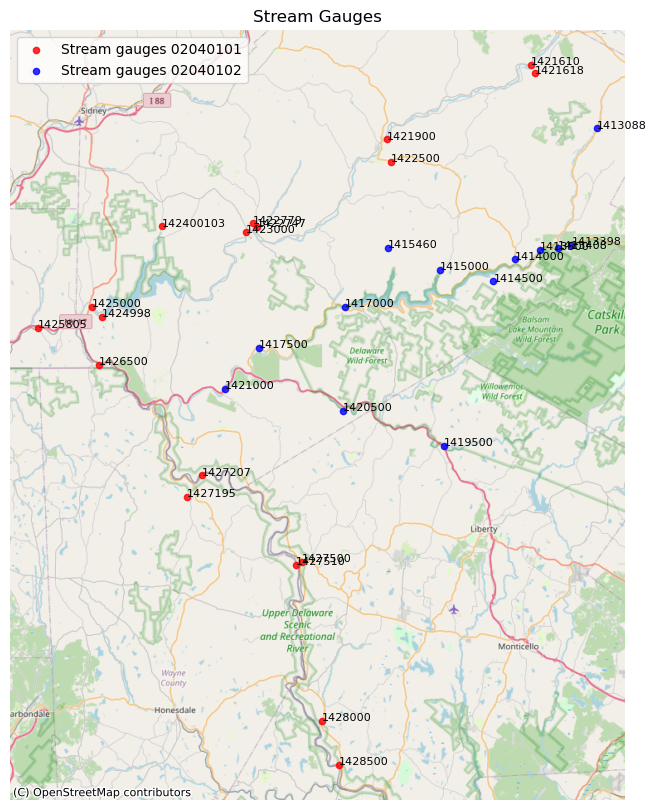

In [27]:

# --- Convert to Web Mercator for basemap ---
gdf = gdf.to_crs(epsg=3857)
gdf01 = gdf01.to_crs(epsg=3857)
gdf02 = gdf02.to_crs(epsg=3857)


# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))

gdf01.plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    label="Stream gauges 02040101"
)

gdf02.plot(
    ax=ax,
    color="blue",
    markersize=20,
    alpha=0.8,
    label="Stream gauges 02040102"
)


# Add basemap 
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.legend(loc="upper left")
# Add labels
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["site_id"]):
    ax.text(x, y, str(label),fontsize=8)

plt.title("Stream Gauges")
plt.show()

## Rename sites and create directed graph

In [78]:
# site_dict = {
#     1421610: "site0",
#     1421618: "site1",
#     1421900: "site2",
#     1422500: "site3",
#     1422747: "site4",
#     1422779: "site5",
#     1423000: "site6",
#     142400103: "site7",
#     1424998: "site8",
#     1425000: "site9",
#     1425805: "site10",
#     1426500: "site11",
#     1427195: "site12",
#     1427207: "site13",
#     1427500: "site14",
#     1427510: "site15",
#     1428000: "site16",
#     1428500: "site17",
#     1413088: "site18",
#     1413398: "site19",
#     1413408: "site20",
#     1413500: "site21",
#     1414000: "site22",
#     1414500: "site23",
#     1415000: "site24",
#     1415460: "site25",
#     1417000: "site26",
#     1417500: "site27",
#     1419500: "site28",
#     1420500: "site29",
#     1421000: "site30"
# }

In [67]:
# List of new site names in the order I specified (from upstream > downstream)
site_rename_list01 = [
    "site0", "site1", "site2", "site3", "site4",
    "site6", "site7", "site9", "site11", "site13",
    "site14", "site15", "site16", "site17", "site5",
    "site10", "site12", "site8"
]

metadata_01["site_rename"] = site_rename_list01


site_rename_list02 = [
    "site18", "site19", "site20", "site21", "site22",
    "site23", "site24", "site25", "site26", "site27",
    "site28", "site29", "site30"
]

metadata_02["site_rename"] = site_rename_list02
metadata_01[['site_id', 'site_name', 'site_rename']]


,site_id,site_name,site_rename
0,1421610,WEST BRANCH DELAWARE RIVER AT HOBART NY,site0
1,1421618,TOWN BROOK SOUTHEAST OF HOBART NY,site1
2,1421900,WEST BRANCH DELAWARE RIVER UPSTREAM FROM DELHI NY,site2
3,1422500,LITTLE DELAWARE RIVER NEAR DELHI NY,site3
4,1422747,EAST BROOK EAST OF WALTON NY,site4
5,1423000,WEST BRANCH DELAWARE RIVER AT WALTON NY,site6
6,142400103,TROUT CREEK NEAR TROUT CREEK NY,site7
7,1425000,WEST BRANCH DELAWARE RIVER AT STILESVILLE NY,site9
8,1426500,WEST BRANCH DELAWARE RIVER AT HALE EDDY NY,site11
9,1427207,DELAWARE RIVER AT LORDVILLE NY,site13


In [ ]:
graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins

In [77]:
river_network = pp.Graph.from_edge_list(graph_edges_all)

# Adjacency matrix 
A = river_network.sparse_adj_matrix()
# print(A.todense())

## Not sure why the order of the nodes is different than the order of site 1 etc. so issue coloring
group0 = ("site0", "site1", "site2", "site3", "site4", "site5", "site6", "site7", "site8", "site9", "site10", "site11", "site12", "site13", "site14", "site15", "site16", "site17")
group1 = ("site18", "site19", "site20", "site21", "site22", "site23", "site24", "site25", "site26", "site27", "site28", "site29", "site30")
z= []
for i, node in enumerate(river_network.nodes):
    if node in group0:
        z.append(0)
    elif node in group1:
        z.append(1)
# z = np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1])

colors = {0: 'red', 1: 'blue'}
pp.plot(river_network, node_color = [colors[z[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids]);

## Adding attributes to nodes

note: All `Node` attributes must be prefixed with `node_`. Just like nodes, `Edge` objects can store arbitrary attributes that we can add as a tensor. The name of the attribute must be prefixed by `edge_`.

### Compute summary statistics

In [ ]:
precipitation = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022_02040101.csv"))

In [60]:
metadata_01

,site_id,site_name,site_type,agency,state,latitude,longitude,first_date_data_available,last_date_data_available,record_count,...,conus2_i,conus2_j,conus2_i_nwm,conus2_j_nwm,gagesii_drainage_area,gagesii_class,gagesii_site_elevation,usgs_drainage_area,usgs_reliability_cd,site_rename
0,1421610,WEST BRANCH DELAWARE RIVER AT HOBART NY,stream gauge,USGS,NY,42.371389,-74.668889,2000-08-11,2026-03-06,9329,...,3958.0,2170.0,3958.0,2170.0,38.8476,Non-ref,495.0,16.0,NaN,site0
1,1421618,TOWN BROOK SOUTHEAST OF HOBART NY,stream gauge,USGS,NY,42.361111,-74.662222,1997-10-01,2026-03-06,10384,...,3958.0,2170.0,3959.0,2169.0,37.3266,Ref,515.0,14.3,NaN,site1
2,1421900,WEST BRANCH DELAWARE RIVER UPSTREAM FROM DELHI NY,stream gauge,USGS,NY,42.280278,-74.907222,1937-04-01,2026-03-06,22918,...,3942.0,2153.0,3942.0,2153.0,347.6808,Non-ref,414.0,134.0,NaN,site2
3,1422500,LITTLE DELAWARE RIVER NEAR DELHI NY,stream gauge,USGS,NY,42.252389,-74.901056,1937-10-01,2026-03-06,22680,...,3943.0,2152.0,3943.0,2152.0,128.9304,Ref,427.0,49.8,NaN,site3
4,1422747,EAST BROOK EAST OF WALTON NY,stream gauge,USGS,NY,42.172667,-75.121917,1998-10-01,2026-03-05,8485,...,3930.0,2139.0,NaN,NaN,63.9018,Ref,383.0,24.7,NaN,site4
5,1423000,WEST BRANCH DELAWARE RIVER AT WALTON NY,stream gauge,USGS,NY,42.166111,-75.140028,1950-10-01,2026-03-05,27547,...,3928.0,2135.0,3928.0,2134.0,859.6809,Ref,366.0,332.0,NaN,site6
6,142400103,TROUT CREEK NEAR TROUT CREEK NY,stream gauge,USGS,NY,42.173583,-75.279444,1952-10-01,2026-03-05,16065,...,3918.0,2137.0,NaN,NaN,52.8453,Ref,356.0,20.2,NaN,site7
7,1425000,WEST BRANCH DELAWARE RIVER AT STILESVILLE NY,stream gauge,USGS,NY,42.074917,-75.395806,1952-07-01,2026-03-06,26910,...,3911.0,2120.0,3911.0,2120.0,1180.5650,Non-ref,307.0,456.0,NaN,site9
8,1426500,WEST BRANCH DELAWARE RIVER AT HALE EDDY NY,stream gauge,USGS,NY,42.003028,-75.383528,1912-11-15,2026-03-05,41367,...,3918.0,2113.0,3918.0,2113.0,1539.3340,Non-ref,295.0,595.0,NaN,site11
9,1427207,DELAWARE RIVER AT LORDVILLE NY,stream gauge,USGS,PA,41.867278,-75.213750,2006-07-28,2026-03-06,7159,...,3935.0,2106.0,3935.0,2106.0,4117.5100,Non-ref,269.0,1590.0,NaN,site13


In [ ]:
streamflow01 = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_02040101.csv"))
streamflow02 = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_02040102.csv"))
streamflow = pd.concat([streamflow01, streamflow02.drop(columns=['date'])], axis=1)
precipitation01 = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022_02040101.csv"))
precipitation02 = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022_02040102.csv"))
precipitation = pd.concat([precipitation01, precipitation02.drop(columns=['date'])], axis=1)

mean_streamflow ={}
std_streamflow = {}
mean_precipitation = {}
std_precipitation = {}

for column in streamflow.columns:
    if column != 'date':
        gauge_name = metadata_01[metadata_01['site_id'] == column]['site_rename'].values[0] if column in metadata_01['site_id'].values else metadata_02[metadata_02['site_id'] == column]['site_rename'].values[0]
        mean_streamflow[gauge_name] = streamflow[column].mean()
        std_streamflow[gauge_name] = streamflow[column].std()

# for column in precipitation.columns:
#     if column != 'date':
#         gauge_name = metadata_01[metadata_01['site_rename'] == column]['site_name'].values[0] if column in metadata_01['site_rename'].values else metadata_02[metadata_02['site_rename'] == column]['site_name'].values[0]
#         rain_days = precipitation[precipitation[column] > 0][column]
#         mean_precipitation[gauge_name] = precipitation[column].mean()
#         std_precipitation[gauge_name] = precipitation[column].std()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
import torch
river_network.data.node_avgprecip = torch.tensor(mean_precipitation)